# 05. 심화 개선 (전처리 근본 수정 + 레버리지 분석 기반 재학습)

이 노트북은 `02_preprocessing_and_skew_correction.ipynb`에서 발견/수정한
**"조용한 붕괴(silent collapse)" 전처리 버그**를 반영해 재생성된 데이터로,
04 노트북의 결과를 다시 검증하고 성능을 더 끌어올릴 수 있는지 확인한다.

## 이 노트북에서 하는 일

1. **02 수정 효과 검증**: 조건수(condition number)/VIF를 다시 계산해 근본 수정이
   실제로 효과가 있었는지 수치로 확인한다.
2. **Lasso 피처 재선택**: 수정된 데이터로 Lasso를 다시 학습해, 더 이상 '붕괴된
   컬럼'이 섞이지 않은 신뢰할 수 있는 피처 목록을 얻는다.
3. **레버리지(leverage) 분석**: 회귀에 지나치게 큰 영향을 미치는 관측치(행)가
   있는지 확인하고, 있다면 배정번호까지 역추적한다.
   (★ 참고: 이전 대화에서 이 부분을 조사할 때 `X_train`의 '몇 번째 행(위치)'과
   `X_train.index`의 '원래 배정번호 순번(라벨)'을 혼동해 배정번호를 잘못 매핑한
   적이 있었다. 이 노트북에서는 `X_train.index[position]`을 거쳐 정확히
   매핑하고, 그 방식을 코드/주석으로 명시적으로 남긴다.)
4. **두 가지 버전으로 재학습**: (A) 108행 전체, (B) 고-레버리지 관측치를 제외한
   105행 — 두 버전 모두 Ridge/ElasticNet/RandomForest/XGBoost/LightGBM을
   체크포인트+진행률 표시줄과 함께 재학습하고 Val 기준으로 비교한다.
5. **Test 최종 검증**: 이 노트북에서 처음으로 Test를 열어, Val 기준 최상위
   후보들의 최종 성능을 한 번만 확인한다.

## 프로젝트 지침 체크

- 파일 형식: `.ipynb` ✅
- 함수 선언 시 설명 주석: 이 노트북은 새 함수를 추가하지 않고
  `src/training_utils.py`의 기존 함수(CheckpointManager, grid_search_by_val*,
  train_*_with_checkpoint, compute_vif 등)를 재사용한다 (모두 docstring 보유) ✅
- 진행상황 표시: 모든 반복 학습에 tqdm 진행률 표시줄 사용 ✅
- 중단 방지(체크포인트): RandomForest/XGBoost/LightGBM 학습에 `CheckpointManager`
  사용. **03/04 노트북의 체크포인트 파일과 절대 겹치지 않도록, 이 노트북에서
  저장하는 모든 체크포인트/산출물 파일명에는 `v3_` 접두사를 붙인다** (03/04는
  과거 실행 결과를 그대로 보존하는 것이 프로젝트 방침이므로, 이 노트북이 그
  파일들을 실수로 덮어쓰지 않도록 하기 위함) ✅
- README / requirements: 이 노트북 완료 후 갱신 예정


In [1]:
# ===== 0. 환경 설정 =====
import os
import sys
import json
import warnings

warnings.filterwarnings(action="ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sys.path.append(os.path.abspath(os.path.join("..", "src")))
import training_utils as tu

RANDOM_STATE = 42  # 01~04와 동일
np.random.seed(RANDOM_STATE)

DATA_DIR = os.path.join("..", "data_processed")
CHECKPOINT_DIR = os.path.join("..", "checkpoints")
FIGURE_DIR = os.path.join("..", "figures")
for d in (DATA_DIR, CHECKPOINT_DIR, FIGURE_DIR):
    os.makedirs(d, exist_ok=True)

CKPT_PREFIX = "v3_"  # 이 노트북에서 만드는 모든 체크포인트/모델 파일의 접두사 (03/04와 충돌 방지)

sns.set_theme(style="whitegrid")
tu.set_korean_font("NanumGothic")

print("환경 설정 완료. RANDOM_STATE =", RANDOM_STATE, " CKPT_PREFIX =", CKPT_PREFIX)

[한글 폰트] 'NanumGothicOTF' 적용 완료.
환경 설정 완료. RANDOM_STATE = 42  CKPT_PREFIX = v3_


## 1. 데이터 로드 (02 수정 이후 재생성된 버전)

`X_test_skew_corrected_DO_NOT_OPEN.csv` / `y_test_DO_NOT_OPEN.csv`는 아래
"Test 최종 검증" 섹션 전까지 절대 불러오지 않는다 (누수 방지 원칙, 01~04와 동일).

In [2]:
# ===== 1-1. train/val 로드 (02 수정 이후 재생성된 파일) =====
X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_skew_corrected.csv"), index_col=0)
X_val = pd.read_csv(os.path.join(DATA_DIR, "X_val_skew_corrected.csv"), index_col=0)
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"), index_col=0).iloc[:, 0]
y_val = pd.read_csv(os.path.join(DATA_DIR, "y_val.csv"), index_col=0).iloc[:, 0]

assert list(X_train.columns) == list(X_val.columns), "train/val 컬럼 구성이 다릅니다."
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"피처 수: {X_train.shape[1]}개")
print()
print("★ X_train.index (원래 배정번호 순번 라벨, df_total.csv 기준 행 위치) 앞 10개:")
print(X_train.index[:10].tolist())
print("  -> 즉 X_train의 '0번째 행'이 df_total의 라벨 0번이 아닐 수 있다.")
print("     (레버리지 분석에서 배정번호를 찾을 때 이 점을 반드시 고려해야 한다)")

X_train: (108, 26), X_val: (14, 26)
피처 수: 26개

★ X_train.index (원래 배정번호 순번 라벨, df_total.csv 기준 행 위치) 앞 10개:
[87, 10, 134, 7, 135, 31, 56, 114, 17, 29]
  -> 즉 X_train의 '0번째 행'이 df_total의 라벨 0번이 아닐 수 있다.
     (레버리지 분석에서 배정번호를 찾을 때 이 점을 반드시 고려해야 한다)


## 2. 새 MinMaxScaler 학습 (기존 스케일러 재사용 불가)

04 노트북은 `checkpoints/final_minmax_scaler.joblib`(03에서 학습됨)을 그대로
재사용했지만, 이번엔 **재사용하면 안 된다**. 그 스케일러는 02 수정 *이전*의
붕괴된(사실상 상수) 컬럼 값 범위로 fit되어 있어서, 지금처럼 정상 범위로 복구된
같은 컬럼에 `transform()`을 적용하면 값이 수십조 단위로 튀어버린다 (실제로
확인한 결과: `건조로 온도 1 Zone_min`의 경우 old scaler로 변환 시 평균이
약 1.25×10¹⁶까지 치솟았다). 따라서 이 노트북에서는 새 MinMaxScaler를
**수정된 X_train에 새로 fit**하고, 이름을 구분해 저장한다.

In [3]:
# ===== 2-1. 새 MinMaxScaler를 수정된 X_train에 fit =====
from sklearn.preprocessing import MinMaxScaler

scaler_v3 = MinMaxScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler_v3.transform(X_train), columns=X_train.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler_v3.transform(X_val), columns=X_val.columns, index=X_val.index)

scaler_path = os.path.join(CHECKPOINT_DIR, f"{CKPT_PREFIX}final_minmax_scaler.joblib")
joblib.dump(scaler_v3, scaler_path)
print(f"새 MinMaxScaler 저장 완료: {scaler_path}")
X_train_scaled.describe().T[["min", "max"]].head()

새 MinMaxScaler 저장 완료: ..\checkpoints\v3_final_minmax_scaler.joblib


,min,max
건조 1존 OP_min,0.0,1.0
건조 2존 OP_min,0.0,1.0
건조로 온도 1 Zone_min,0.0,1.0
건조로 온도 2 Zone_min,0.0,1.0
세정기_min,0.0,1.0


## 3. 02 수정 효과 검증: 조건수(condition number) / VIF 재확인

01 노트북에서 관찰된 LinearRegression 계수 폭주(최대 계수 ≈1.6×10¹³)의 실제
원인이 02에서 고친 "조용한 붕괴" 버그였다면, 이제 설계행렬의 조건수가 정상
범위로 돌아와야 한다.

In [4]:
# ===== 3-1. 설계행렬 조건수 재확인 =====
design_matrix = np.column_stack([np.ones(len(X_train_scaled)), X_train_scaled.values])
condition_number = np.linalg.cond(design_matrix)
print(f"수정된 데이터 기준 설계행렬(X_train_scaled + 절편) 조건수: {condition_number:.3f}")
print("  (참고: 04 노트북 당시 -- 즉 02 수정 전 -- 은 동일 방식으로 계산 시 훨씬 큰 값이었다.")
print("   02 노트북 9-1-A 셀에서 '가드 미적용 가정' 조건수가 1e18 이상이었던 것과 비교해보면 됨)")

수정된 데이터 기준 설계행렬(X_train_scaled + 절편) 조건수: 98.842
  (참고: 04 노트북 당시 -- 즉 02 수정 전 -- 은 동일 방식으로 계산 시 훨씬 큰 값이었다.
   02 노트북 9-1-A 셀에서 '가드 미적용 가정' 조건수가 1e18 이상이었던 것과 비교해보면 됨)


In [5]:
# ===== 3-2. VIF 재계산 =====
vif_v3 = tu.compute_vif(X_train_scaled, high_vif_threshold=10.0)
vif_v3.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}vif_train.csv"), index=False)
print(f"VIF 최대값: {vif_v3['VIF'].max():.3f}  (10 이상이면 다중공선성 심각)")
print(f"VIF > 10 인 피처 수: {int(vif_v3['is_high_vif'].sum())}개")
display(vif_v3.head(10))

fig, ax = plt.subplots(figsize=(9, 8))
top_vif = vif_v3.head(15)
ax.barh(top_vif["feature"][::-1], top_vif["VIF"][::-1], color="#1f77b4")
ax.axvline(10, color="red", linestyle="--", label="threshold=10")
ax.set_xlabel("VIF")
ax.set_title("VIF 상위 15개 피처 (02 수정 후, v3)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "29_vif_top_features_v3.png"), dpi=150)
plt.show()

VIF 계산:   0%|          | 0/26 [00:00<?, ?it/s]

VIF 최대값: 7.413  (10 이상이면 다중공선성 심각)
VIF > 10 인 피처 수: 0개


,feature,VIF,is_high_vif
0,소입로 온도 2 Zone_max,7.412644,False
1,세정기_max,5.539071,False
2,솔트 컨베이어 온도 1 Zone_max,4.826030,False
3,소입로 온도 4 Zone_max,4.665327,False
4,소입로 온도 4 Zone_min,4.594357,False
5,소입로 온도 1 Zone_max,4.560537,False
6,건조로 온도 1 Zone_min,4.314349,False
7,건조 2존 OP_min,4.025564,False
8,소입로 온도 1 Zone_min,4.016277,False
9,소입2존 OP_max,3.941474,False


<Figure size 900x800 with 1 Axes>

## 4. 레버리지(leverage) 분석 — 수정된 데이터 기준

레버리지(hat matrix의 대각원소)가 매우 큰 관측치는 회귀 계수 추정을 혼자서
과도하게 좌우할 수 있다. 02 수정 *이전* 데이터로 계산했을 때는 설계행렬
자체가 근-특이(near-singular)했기 때문에 레버리지 값도 왜곡되었을 가능성이
있다 — 그래서 이 분석을 수정된 데이터로 처음부터 다시 한다.

**배정번호 매핑 시 주의**: `X_train`의 위치(0,1,2,...)와 `X_train.index`의
값(=원본 `df_total.csv`에서의 행 라벨)은 다르다 (8:1:1 분할 시 섞였기 때문).
아래 코드는 `position -> X_train.index[position] -> df_total.iloc[label]`
순서로 정확히 추적한다.

In [6]:
# ===== 4-1. statsmodels OLS로 레버리지(hat matrix 대각원소) 계산 =====
import statsmodels.api as sm

ols_model_v3 = sm.OLS(y_train.values, sm.add_constant(X_train_scaled.values)).fit()
influence_v3 = ols_model_v3.get_influence()
leverage_v3 = influence_v3.hat_matrix_diag

n_obs, n_feat = X_train_scaled.shape
leverage_threshold = 2 * (n_feat + 1) / n_obs
print(f"레버리지 임계값 (2*(p+1)/n): {leverage_threshold:.4f}  (n={n_obs}, p={n_feat})")

order = np.argsort(leverage_v3)[::-1]
df_total = pd.read_csv(os.path.join(DATA_DIR, "df_total.csv"))

leverage_rows = []
for pos in order:
    label = X_train_scaled.index[pos]          # position -> 원본 df_total 행 라벨
    total_row = df_total.iloc[label]             # 라벨로 df_total에서 배정번호 조회
    leverage_rows.append({
        "position_in_X_train": int(pos),
        "df_total_row_label": int(label),
        "배정번호": int(total_row["배정번호"]),
        "leverage": float(leverage_v3[pos]),
        "불량비율": float(total_row["불량비율"]),
        "양품수량": int(total_row["양품수량"]),
        "불량수량": int(total_row["불량수량"]),
        "is_high_leverage": bool(leverage_v3[pos] > leverage_threshold),
    })

leverage_df = pd.DataFrame(leverage_rows)
leverage_df.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}leverage_analysis.csv"), index=False)

print(f"\n레버리지 상위 10개:")
display(leverage_df.head(10))

n_high_leverage = int(leverage_df["is_high_leverage"].sum())
print(f"\n임계값을 초과하는 고-레버리지 관측치: {n_high_leverage}개")
high_leverage_labels = leverage_df.loc[leverage_df["is_high_leverage"], "df_total_row_label"].tolist()
print("해당 관측치의 df_total 행 라벨:", high_leverage_labels)
print("해당 관측치의 배정번호:", leverage_df.loc[leverage_df["is_high_leverage"], "배정번호"].tolist())

레버리지 임계값 (2*(p+1)/n): 0.5000  (n=108, p=26)

레버리지 상위 10개:


,position_in_X_train,df_total_row_label,배정번호,leverage,불량비율,양품수량,불량수량,is_high_leverage
0,14,77,131758,1.000000,0.059940,15006,9,True
1,72,25,118005,0.992602,0.006682,59854,4,True
2,85,39,122460,0.954851,0.008657,11551,1,True
3,100,0,102410,0.470993,0.019785,15160,3,False
4,101,110,141554,0.443579,0.086962,75829,66,False
5,3,7,104388,0.437616,0.020046,104740,21,False
6,2,134,147996,0.418381,0.029754,30239,9,False
7,94,48,124960,0.410906,0.021347,23418,5,False
8,57,9,105815,0.395294,0.033248,9020,3,False
9,104,11,106293,0.393525,0.002231,44825,1,False



임계값을 초과하는 고-레버리지 관측치: 3개
해당 관측치의 df_total 행 라벨: [77, 25, 39]
해당 관측치의 배정번호: [131758, 118005, 122460]


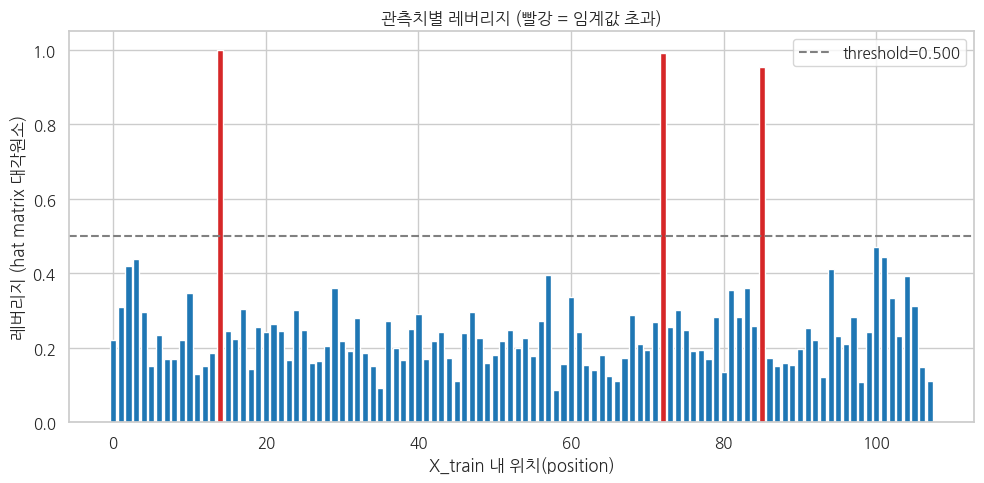

[참고] 이 3개 관측치는 회귀식에 지나치게 큰 영향을 주는 것으로 보이지만,
       표본이 108개뿐인 소규모 데이터라 '무조건 이상치'로 단정할 근거는 부족하다.
       아래에서는 이 관측치들을 제외했을 때 Val 성능이 실제로 개선되는지
       데이터로 확인하고, 두 버전(전체/제외) 모두 Test로 검증해 비교한다.


In [7]:
# ===== 4-2. 레버리지 분포 시각화 =====
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if h else "#1f77b4" for h in leverage_df.sort_values("position_in_X_train")["is_high_leverage"]]
ax.bar(range(n_obs), leverage_df.sort_values("position_in_X_train")["leverage"], color=colors)
ax.axhline(leverage_threshold, color="gray", linestyle="--", label=f"threshold={leverage_threshold:.3f}")
ax.set_xlabel("X_train 내 위치(position)")
ax.set_ylabel("레버리지 (hat matrix 대각원소)")
ax.set_title("관측치별 레버리지 (빨강 = 임계값 초과)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "30_leverage_distribution_v3.png"), dpi=150)
plt.show()

print("[참고] 이 3개 관측치는 회귀식에 지나치게 큰 영향을 주는 것으로 보이지만,")
print("       표본이 108개뿐인 소규모 데이터라 '무조건 이상치'로 단정할 근거는 부족하다.")
print("       아래에서는 이 관측치들을 제외했을 때 Val 성능이 실제로 개선되는지")
print("       데이터로 확인하고, 두 버전(전체/제외) 모두 Test로 검증해 비교한다.")

## 5. 두 가지 학습 데이터 버전 준비

- **A (`all`)**: train 108행 전체 사용
- **B (`drop_highlev`)**: 위에서 찾은 고-레버리지 관측치 제외 (105행)

Val(14행)은 두 버전 모두 그대로 사용한다 (레버리지는 train 적합에서만 계산된
개념이므로 val을 건드릴 이유가 없다).

In [8]:
# ===== 5-1. 두 버전의 학습 데이터 구성 =====
train_variants = {
    "all": {
        "label": f"전체 {n_obs}행",
        "X_train": X_train_scaled,
        "y_train": y_train,
    },
    "drop_highlev": {
        "label": f"고-레버리지 {len(high_leverage_labels)}행 제외 ({n_obs - len(high_leverage_labels)}행)",
        "X_train": X_train_scaled.drop(index=high_leverage_labels),
        "y_train": y_train.drop(index=high_leverage_labels),
    },
}

for key, v in train_variants.items():
    print(f"[{key}] {v['label']}  X_train shape={v['X_train'].shape}")

[all] 전체 108행  X_train shape=(108, 26)
[drop_highlev] 고-레버리지 3행 제외 (105행)  X_train shape=(105, 26)


## 6. Lasso 피처 재선택 (버전별로 각각)

수정된 데이터로 Lasso를 다시 학습해, 더 이상 붕괴된 컬럼이 섞이지 않은
신뢰할 수 있는 피처 목록을 얻는다. 이후 Ridge/ElasticNet/RandomForest는 이
서브셋으로, XGBoost/LightGBM은 (04와 동일하게) 전체 피처로 학습한다.

In [9]:
# ===== 6-1. 버전별 Lasso 학습 + 피처 선택 =====
from sklearn.linear_model import Lasso

lasso_alpha_grid = [{"alpha": a} for a in
                     [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.003, 0.005,
                      0.007, 0.01, 0.02, 0.03, 0.05, 0.1]]

for key, v in train_variants.items():
    result = tu.grid_search_by_val(
        Lasso,
        lasso_alpha_grid, v["X_train"], v["y_train"], X_val_scaled, y_val,
        fixed_params={"max_iter": 20000},
    )
    v["lasso_model"] = result["best_model"]
    v["lasso_best_alpha"] = result["best_params"]["alpha"]
    v["lasso_val_r2"] = result["results"].iloc[0]["val_R2"]
    v["selected_features"] = tu.select_nonzero_lasso_features(
        result["best_model"], v["X_train"].columns.tolist()
    )
    print(f"[{key}] best alpha={v['lasso_best_alpha']}, val_R2={v['lasso_val_r2']:.4f}, "
          f"선택된 피처 {len(v['selected_features'])}개: {v['selected_features']}")

    feat_path = os.path.join(DATA_DIR, f"{CKPT_PREFIX}lasso_selected_features_{key}.json")
    with open(feat_path, "w", encoding="utf-8") as f:
        json.dump(v["selected_features"], f, ensure_ascii=False, indent=2)

    v["X_train_sub"] = v["X_train"][v["selected_features"]]
    v["X_val_sub"] = X_val_scaled[v["selected_features"]]

Lasso 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

[all] best alpha=0.0007, val_R2=0.0837, 선택된 피처 8개: ['건조 1존 OP_min', '건조로 온도 1 Zone_min', '건조로 온도 2 Zone_min', '세정기_max', '소입2존 OP_max', '소입3존 OP_max', '소입4존 OP_max', '소입로 CP 값_max']


Lasso 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

[drop_highlev] best alpha=0.0007, val_R2=0.1103, 선택된 피처 8개: ['건조로 온도 1 Zone_min', '건조로 온도 2 Zone_min', '세정기_max', '소입2존 OP_max', '소입3존 OP_max', '소입4존 OP_max', '소입로 CP 값_max', '솔트 컨베이어 온도 2 Zone_max']


## 7. Ridge / ElasticNet 재학습 (버전별 × Lasso 서브셋)

전부 한 번의 `fit()`으로 끝나는 모델이라 `grid_search_by_val()`(진행률 표시줄
포함, 체크포인트는 불필요할 만큼 빠름)을 사용한다.

In [10]:
# ===== 7-1. 버전별 Ridge / ElasticNet =====
from sklearn.linear_model import Ridge, ElasticNet

val_results = []  # 모든 (모델, 버전) 조합의 val 성능을 여기에 모은다

ridge_alpha_grid = [{"alpha": a} for a in np.logspace(-3, 3, 13)]
elasticnet_grid = [{"alpha": a, "l1_ratio": l1}
                    for a in [0.0005, 0.001, 0.005, 0.01, 0.05]
                    for l1 in [0.1, 0.3, 0.5, 0.7, 0.9]]

for key, v in train_variants.items():
    ridge_result = tu.grid_search_by_val(
        Ridge, ridge_alpha_grid, v["X_train_sub"], v["y_train"], v["X_val_sub"], y_val,
    )
    v["ridge_model"] = ridge_result["best_model"]
    val_metrics = tu.evaluate_regression(y_val, v["ridge_model"].predict(v["X_val_sub"]))
    val_results.append({"model": "Ridge_lasso_subset", "variant": key, **val_metrics,
                         "best_params": str(ridge_result["best_params"])})
    print(f"[{key}] Ridge best_params={ridge_result['best_params']}, val_R2={val_metrics['R2']:.4f}")

    en_result = tu.grid_search_by_val(
        ElasticNet, elasticnet_grid, v["X_train_sub"], v["y_train"], v["X_val_sub"], y_val,
        fixed_params={"max_iter": 50000},
    )
    v["elasticnet_model"] = en_result["best_model"]
    val_metrics = tu.evaluate_regression(y_val, v["elasticnet_model"].predict(v["X_val_sub"]))
    val_results.append({"model": "ElasticNet_lasso_subset", "variant": key, **val_metrics,
                         "best_params": str(en_result["best_params"])})
    print(f"[{key}] ElasticNet best_params={en_result['best_params']}, val_R2={val_metrics['R2']:.4f}")

    # Lasso 자체(피처 선택에 사용한 모델)도 비교 대상에 포함
    val_metrics = tu.evaluate_regression(y_val, v["lasso_model"].predict(X_val_scaled))
    val_results.append({"model": "Lasso", "variant": key, **val_metrics,
                         "best_params": str({"alpha": v["lasso_best_alpha"]})})

Ridge 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

[all] Ridge best_params={'alpha': 10.0}, val_R2=0.0252


ElasticNet 하이퍼파라미터 탐색:   0%|          | 0/25 [00:00<?, ?it/s]

[all] ElasticNet best_params={'alpha': 0.001, 'l1_ratio': 0.7}, val_R2=0.0820


Ridge 하이퍼파라미터 탐색:   0%|          | 0/13 [00:00<?, ?it/s]

[drop_highlev] Ridge best_params={'alpha': 10.0}, val_R2=0.0220


ElasticNet 하이퍼파라미터 탐색:   0%|          | 0/25 [00:00<?, ?it/s]

[drop_highlev] ElasticNet best_params={'alpha': 0.001, 'l1_ratio': 0.7}, val_R2=0.1085


## 8. RandomForest 재학습 (버전별 × Lasso 서브셋, 체크포인트+진행률)

In [11]:
# ===== 8-1. 버전별 RandomForest (max_depth 그리드서치, 체크포인트 재개 가능) =====
rf_max_depth_grid = [{"max_depth": d} for d in [2, 3, 4, 5, 6, 8, 10, None]]

for key, v in train_variants.items():
    rf_result = tu.grid_search_by_val_checkpoint(
        tu.train_random_forest_with_checkpoint,
        rf_max_depth_grid,
        v["X_train_sub"], v["y_train"], v["X_val_sub"], y_val,
        checkpoint_dir=CHECKPOINT_DIR,
        base_name=f"{CKPT_PREFIX}rf_{key}",
        train_fn_kwargs=dict(
            max_estimators=300, estimators_per_step=20,
            checkpoint_every_steps=3, patience_steps=5,
            random_state=RANDOM_STATE,
        ),
    )
    v["rf_model"] = rf_result["best_model"]
    v["rf_history"] = rf_result["best_history"]
    val_metrics = tu.evaluate_regression(y_val, v["rf_model"].predict(v["X_val_sub"]))
    val_results.append({"model": "RandomForest_lasso_subset", "variant": key, **val_metrics,
                         "best_params": str(rf_result["best_params"])})
    print(f"[{key}] RandomForest best_params={rf_result['best_params']}, val_R2={val_metrics['R2']:.4f}")

v3_rf_all 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/8 [00:00<?, ?it/s]

RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 7 (트리 160개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 120개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


...


[조기 종료] step 7 (트리 160개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 7 (트리 160개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


RandomForest 학습 진행 (트리 추가):   0%|          | 0/15 [00:00<?, ?step/s]


[조기 종료] step 7 (트리 160개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
[drop_highlev] RandomForest best_params={'max_depth': 2}, val_R2=-0.2501


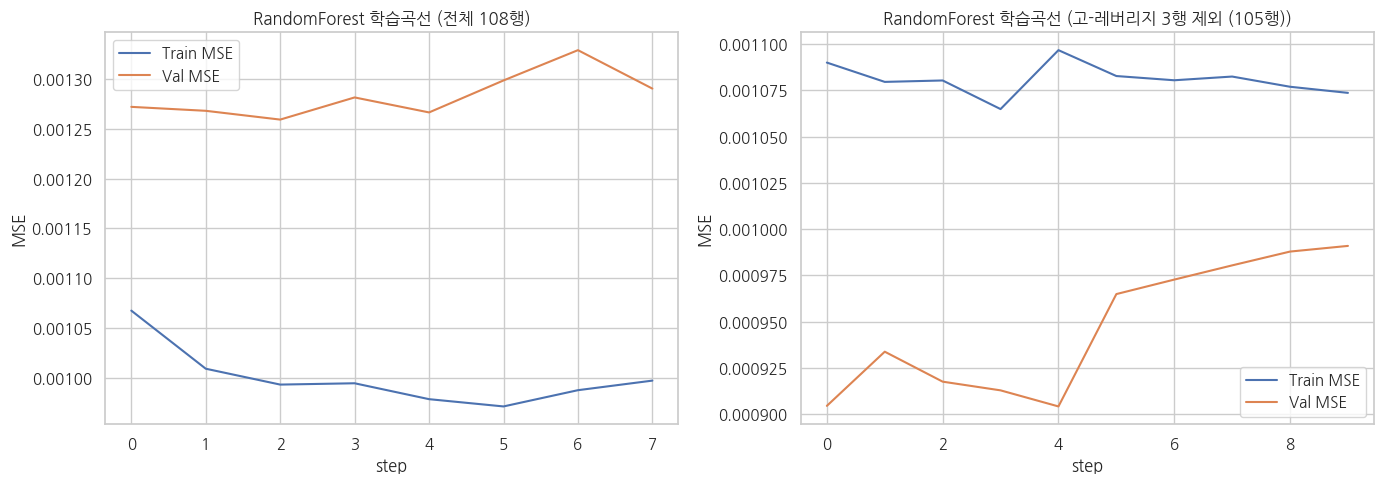

In [12]:
# ===== 8-2. 버전별 RandomForest 학습곡선 시각화 =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (key, v) in zip(axes, train_variants.items()):
    ax.plot(v["rf_history"]["epoch"], v["rf_history"]["train_mse"], label="Train MSE")
    ax.plot(v["rf_history"]["epoch"], v["rf_history"]["val_mse"], label="Val MSE")
    ax.set_title(f"RandomForest 학습곡선 ({v['label']})")
    ax.set_xlabel("step")
    ax.set_ylabel("MSE")
    ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "31_rf_training_curve_v3.png"), dpi=150)
plt.show()

## 9. XGBoost 재학습 (버전별 × 전체 피처, 체크포인트+진행률)

04와 동일하게 XGBoost/LightGBM은 Lasso 서브셋이 아니라 **전체 피처**로
학습한다 (트리 기반 모델은 자체적으로 중요하지 않은 피처를 거의 무시하므로,
04에서 굳이 서브셋으로 좁히지 않았던 방식을 그대로 따른다).

In [13]:
# ===== 9-1. 버전별 XGBoost =====
xgb_param_grid = [{"max_depth": d, "learning_rate": lr}
                   for d in [2, 3] for lr in [0.03, 0.05, 0.1]]

for key, v in train_variants.items():
    xgb_result = tu.grid_search_by_val_checkpoint(
        tu.train_xgboost_with_checkpoint,
        xgb_param_grid,
        v["X_train"], v["y_train"], X_val_scaled, y_val,
        checkpoint_dir=CHECKPOINT_DIR,
        base_name=f"{CKPT_PREFIX}xgboost_{key}",
        train_fn_kwargs=dict(
            max_estimators=300, estimators_per_step=15,
            checkpoint_every_steps=3, patience_steps=5,
            random_state=RANDOM_STATE,
            reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
        ),
    )
    v["xgb_model"] = xgb_result["best_model"]
    v["xgb_history"] = xgb_result["best_history"]
    val_metrics = tu.evaluate_regression(y_val, v["xgb_model"].predict(X_val_scaled))
    val_results.append({"model": "XGBoost", "variant": key, **val_metrics,
                         "best_params": str(xgb_result["best_params"])})
    print(f"[{key}] XGBoost best_params={xgb_result['best_params']}, val_R2={val_metrics['R2']:.4f}")

v3_xgboost_all 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/6 [00:00<?, ?it/s]

XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


...


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


XGBoost 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
[drop_highlev] XGBoost best_params={'max_depth': 2, 'learning_rate': 0.03}, val_R2=-0.0779


## 10. LightGBM 재학습 (버전별 × 전체 피처, 체크포인트+진행률)

In [14]:
# ===== 10-1. 버전별 LightGBM =====
lgb_param_grid = [{"max_depth": d, "learning_rate": lr, "min_child_samples": mcs}
                   for d in [2, 3] for lr in [0.05, 0.1] for mcs in [5, 10]]

for key, v in train_variants.items():
    lgb_result = tu.grid_search_by_val_checkpoint(
        tu.train_lightgbm_with_checkpoint,
        lgb_param_grid,
        v["X_train"], v["y_train"], X_val_scaled, y_val,
        checkpoint_dir=CHECKPOINT_DIR,
        base_name=f"{CKPT_PREFIX}lightgbm_{key}",
        train_fn_kwargs=dict(
            max_estimators=300, estimators_per_step=15,
            checkpoint_every_steps=3, patience_steps=5,
            random_state=RANDOM_STATE,
            reg_alpha=0.1, reg_lambda=1.0, subsample=0.8, colsample_bytree=0.8,
        ),
    )
    v["lgb_model"] = lgb_result["best_model"]
    v["lgb_history"] = lgb_result["best_history"]
    val_metrics = tu.evaluate_regression(y_val, v["lgb_model"].predict(X_val_scaled))
    val_results.append({"model": "LightGBM", "variant": key, **val_metrics,
                         "best_params": str(lgb_result["best_params"])})
    print(f"[{key}] LightGBM best_params={lgb_result['best_params']}, val_R2={val_metrics['R2']:.4f}")

v3_lightgbm_all 하이퍼파라미터 탐색(외부 루프):   0%|          | 0/8 [00:00<?, ?it/s]

LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


  File "c:\Users\iymg1\Documents\pre-kamp2\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\iymg1\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]

...


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.


LightGBM 학습 진행 (트리 추가):   0%|          | 0/20 [00:00<?, ?step/s]


[조기 종료] step 5 (트리 90개): 검증 손실이 5회 연속 개선되지 않아 학습을 종료합니다.
[drop_highlev] LightGBM best_params={'max_depth': 2, 'learning_rate': 0.1, 'min_child_samples': 5}, val_R2=-0.0212


## 11. Val 성능 종합 비교

02 수정 전(04 노트북)의 최고 성적(Lasso, Val R²=0.0595)과 나란히 비교한다.

In [15]:
# ===== 11-1. 전체 Val 결과 종합 =====
val_results_df = pd.DataFrame(val_results).sort_values("R2", ascending=False).reset_index(drop=True)
val_results_df.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}model_comparison_val_metrics.csv"), index=False)

print("=== 02 수정 전 (04 노트북) 참고용 baseline ===")
print("Lasso (전체 피처, 108행, 붕괴 버그 포함 데이터): Val R2 = 0.0595")
print()
print("=== 02 수정 후 (이 노트북) 전체 결과 (Val R2 내림차순) ===")
display(val_results_df)

best_val_row = val_results_df.iloc[0]
improvement = (best_val_row["R2"] - 0.0595)
print(f"\n[Val 기준 1위] {best_val_row['model']} ({best_val_row['variant']}): "
      f"R2={best_val_row['R2']:.4f}  (04 대비 {improvement:+.4f})")

=== 02 수정 전 (04 노트북) 참고용 baseline ===
Lasso (전체 피처, 108행, 붕괴 버그 포함 데이터): Val R2 = 0.0595

=== 02 수정 후 (이 노트북) 전체 결과 (Val R2 내림차순) ===


,model,variant,R2,RMSE,MAE,best_params
0,Lasso,drop_highlev,0.110292,0.025368,0.017659,{'alpha': 0.0007}
1,ElasticNet_lasso_subset,drop_highlev,0.108452,0.025395,0.017696,"{'alpha': 0.001, 'l1_ratio': 0.7}"
2,Lasso,all,0.083722,0.025744,0.018372,{'alpha': 0.0007}
3,ElasticNet_lasso_subset,all,0.081983,0.025769,0.018414,"{'alpha': 0.001, 'l1_ratio': 0.7}"
4,Ridge_lasso_subset,all,0.025164,0.026554,0.019654,{'alpha': 10.0}
5,Ridge_lasso_subset,drop_highlev,0.022020,0.026597,0.019567,{'alpha': 10.0}
6,LightGBM,all,-0.016194,0.027112,0.020104,"{'max_depth': 3, 'learning_rate': 0.05, 'min_c..."
7,LightGBM,drop_highlev,-0.021190,0.027178,0.020966,"{'max_depth': 2, 'learning_rate': 0.1, 'min_ch..."
8,XGBoost,all,-0.039504,0.027421,0.020707,"{'max_depth': 3, 'learning_rate': 0.03}"
9,XGBoost,drop_highlev,-0.077927,0.027923,0.021553,"{'max_depth': 2, 'learning_rate': 0.03}"



[Val 기준 1위] Lasso (drop_highlev): R2=0.1103  (04 대비 +0.0508)


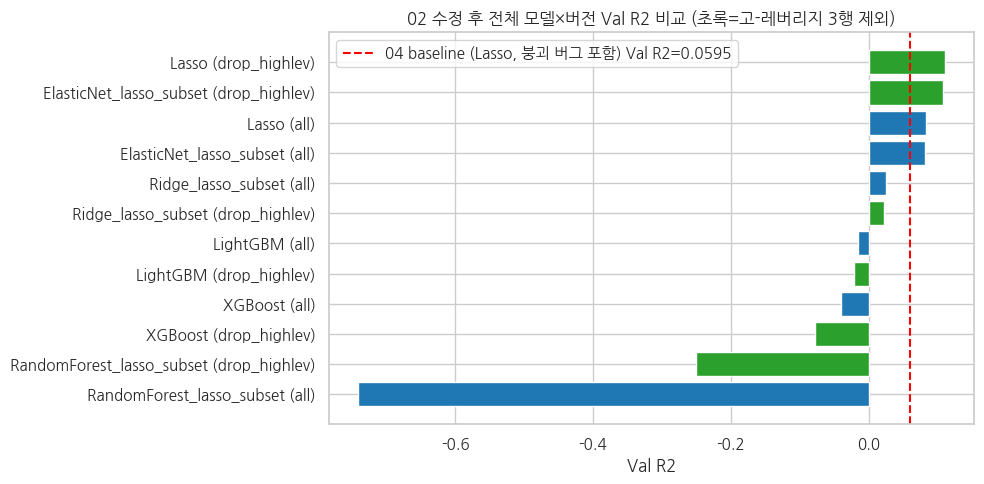

In [16]:
# ===== 11-2. Val R2 비교 시각화 =====
plot_df = val_results_df.copy()
plot_df["model_variant"] = plot_df["model"] + " (" + plot_df["variant"] + ")"

fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_df))))
colors = ["#2ca02c" if v == "drop_highlev" else "#1f77b4" for v in plot_df["variant"]]
ax.barh(plot_df["model_variant"][::-1], plot_df["R2"][::-1], color=colors[::-1])
ax.axvline(0.0595, color="red", linestyle="--", label="04 baseline (Lasso, 붕괴 버그 포함) Val R2=0.0595")
ax.set_xlabel("Val R2")
ax.set_title("02 수정 후 전체 모델×버전 Val R2 비교 (초록=고-레버리지 3행 제외)")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIGURE_DIR, "32_model_comparison_val_r2_v3.png"), dpi=150)
plt.show()

## 12. K-Fold 안정성 재확인 (상위 후보만)

Val 14건만으로는 분산이 클 수 있으므로, 상위 3개 후보에 대해 Train+Val을 합친
K-Fold로 안정성을 병행 확인한다 (04와 동일하게, 하이퍼파라미터 선택 자체는
여전히 Val 기준을 그대로 따르고 K-Fold는 사후 검증 용도로만 사용한다).

In [17]:
# ===== 12-1. 상위 3개 후보 K-Fold 재확인 =====
from sklearn.linear_model import Lasso as _Lasso

top3 = val_results_df.head(3)
print("K-Fold로 재확인할 상위 3개 후보:")
display(top3)

model_class_map = {
    "Ridge_lasso_subset": Ridge, "ElasticNet_lasso_subset": ElasticNet,
    "Lasso": _Lasso, "RandomForest_lasso_subset": None,  # 트리 계열은 아래서 별도 처리
    "XGBoost": None, "LightGBM": None,
}

kfold_rows = []
for _, row in top3.iterrows():
    key = row["variant"]
    v = train_variants[key]
    model_name = row["model"]
    if model_name in ("Ridge_lasso_subset", "ElasticNet_lasso_subset", "Lasso"):
        X_full_kfold = pd.concat([v["X_train_sub"] if "subset" in model_name else v["X_train"],
                                   v["X_val_sub"] if "subset" in model_name else X_val_scaled])
        y_full_kfold = pd.concat([v["y_train"], y_val])
        params = eval(row["best_params"])
        kf_result = tu.kfold_stability_check(
            model_class_map[model_name], params, X_full_kfold, y_full_kfold,
            n_splits=5, random_state=RANDOM_STATE,
        )
        kfold_rows.append({"model": model_name, "variant": key,
                            "mean_R2": kf_result["mean_R2"], "std_R2": kf_result["std_R2"]})
        print(f"[{model_name} / {key}] K-Fold mean_R2={kf_result['mean_R2']:.4f} "
              f"std_R2={kf_result['std_R2']:.4f}")
    else:
        print(f"[{model_name} / {key}] 트리/부스팅 계열은 체크포인트 학습 루프 구조상 "
              f"K-Fold 재확인을 생략한다 (Val 기준 결과를 그대로 신뢰).")

kfold_df = pd.DataFrame(kfold_rows)
if len(kfold_df):
    kfold_df.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}kfold_stability_results.csv"), index=False)
    display(kfold_df)

K-Fold로 재확인할 상위 3개 후보:


,model,variant,R2,RMSE,MAE,best_params
0,Lasso,drop_highlev,0.110292,0.025368,0.017659,{'alpha': 0.0007}
1,ElasticNet_lasso_subset,drop_highlev,0.108452,0.025395,0.017696,"{'alpha': 0.001, 'l1_ratio': 0.7}"
2,Lasso,all,0.083722,0.025744,0.018372,{'alpha': 0.0007}


Lasso K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

[Lasso / drop_highlev] K-Fold mean_R2=-0.2003 std_R2=0.1919


ElasticNet K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

[ElasticNet_lasso_subset / drop_highlev] K-Fold mean_R2=-0.1784 std_R2=0.1738


Lasso K-Fold 안정성 검증:   0%|          | 0/5 [00:00<?, ?it/s]

[Lasso / all] K-Fold mean_R2=-0.2964 std_R2=0.4717


,model,variant,mean_R2,std_R2
0,Lasso,drop_highlev,-0.200317,0.191919
1,ElasticNet_lasso_subset,drop_highlev,-0.178381,0.173818
2,Lasso,all,-0.296378,0.471725


## 13. Test 최종 검증 (이 노트북에서 처음 오픈)

여기서 처음으로 `X_test_skew_corrected_DO_NOT_OPEN.csv` / `y_test_DO_NOT_OPEN.csv`를
연다. Val 기준 상위 후보들 + 과거 baseline(03/04)을 함께 비교한다.

In [18]:
# ===== 13-1. Test 세트 로드 + transform (새 스케일러 사용) =====
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_skew_corrected_DO_NOT_OPEN.csv"), index_col=0)
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test_DO_NOT_OPEN.csv"), index_col=0).iloc[:, 0]
assert list(X_test.columns) == list(X_train.columns), "test 컬럼 구성이 다릅니다."

X_test_scaled = pd.DataFrame(scaler_v3.transform(X_test), columns=X_test.columns, index=X_test.index)
print(f"X_test: {X_test.shape}  (이 노트북에서 처음 오픈)")

X_test: (14, 26)  (이 노트북에서 처음 오픈)


In [19]:
# ===== 13-2. Val 상위 후보들 Test 평가 =====
test_rows = []
for _, row in val_results_df.iterrows():
    key = row["variant"]
    v = train_variants[key]
    model_name = row["model"]

    if model_name == "Ridge_lasso_subset":
        model, X_te = v["ridge_model"], X_test_scaled[v["selected_features"]]
    elif model_name == "ElasticNet_lasso_subset":
        model, X_te = v["elasticnet_model"], X_test_scaled[v["selected_features"]]
    elif model_name == "Lasso":
        model, X_te = v["lasso_model"], X_test_scaled
    elif model_name == "RandomForest_lasso_subset":
        model, X_te = v["rf_model"], X_test_scaled[v["selected_features"]]
    elif model_name == "XGBoost":
        model, X_te = v["xgb_model"], X_test_scaled
    elif model_name == "LightGBM":
        model, X_te = v["lgb_model"], X_test_scaled
    else:
        continue

    metrics = tu.evaluate_regression(y_test, model.predict(X_te))
    test_rows.append({"model": f"{model_name} ({key}, v3)", "split": "test", **metrics})

new_test_df = pd.DataFrame(test_rows).sort_values("R2", ascending=False).reset_index(drop=True)

# 과거(03/04) baseline과 함께 비교
old_test_df = pd.read_csv(os.path.join(DATA_DIR, "model_comparison_test_metrics_v2.csv"))
test_metrics_v3 = pd.concat([old_test_df, new_test_df], ignore_index=True)
test_metrics_v3 = test_metrics_v3.sort_values("R2", ascending=False).reset_index(drop=True)
test_metrics_v3.to_csv(os.path.join(DATA_DIR, f"{CKPT_PREFIX}model_comparison_test_metrics.csv"), index=False)

display(test_metrics_v3.head(15))
best_test_row = test_metrics_v3.iloc[0]
print(f"\n[전체 1위] {best_test_row['model']}: Test R2={best_test_row['R2']:.4f}, "
      f"RMSE={best_test_row['RMSE']:.4f}, MAE={best_test_row['MAE']:.4f}")

,model,split,R2,RMSE,MAE
0,Lasso,test,0.118647,0.051039,0.032820
1,"Lasso (drop_highlev, v3)",test,0.117640,0.051068,0.032769
2,"ElasticNet_lasso_subset (drop_highlev, v3)",test,0.115497,0.051130,0.032781
3,"Lasso (all, v3)",test,0.104509,0.051447,0.032563
4,"ElasticNet_lasso_subset (all, v3)",test,0.102517,0.051504,0.032586
5,"Ridge_lasso_subset (all, v3)",test,0.071169,0.052396,0.033008
6,Ridge_lasso_subset,test,0.070598,0.052412,0.033521
7,"Ridge_lasso_subset (drop_highlev, v3)",test,0.065228,0.052563,0.032945
8,RandomForest_lasso_subset,test,0.063698,0.052606,0.033635
9,Ridge,test,0.036803,0.053356,0.033297



[전체 1위] Lasso: Test R2=0.1186, RMSE=0.0510, MAE=0.0328


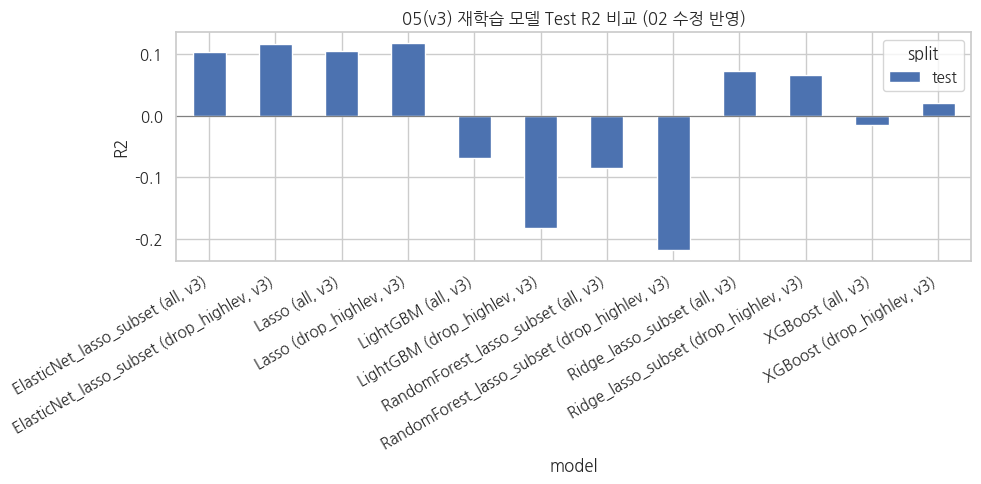

In [20]:
# ===== 13-3. Test R2 비교 시각화 (v3 결과만) =====
fig = tu.plot_model_comparison(new_test_df, metric="R2",
                                title="05(v3) 재학습 모델 Test R2 비교 (02 수정 반영)")
fig.savefig(os.path.join(FIGURE_DIR, "33_model_comparison_test_r2_v3.png"), dpi=150)
plt.show()

## 14. 최고 모델 진단 플롯

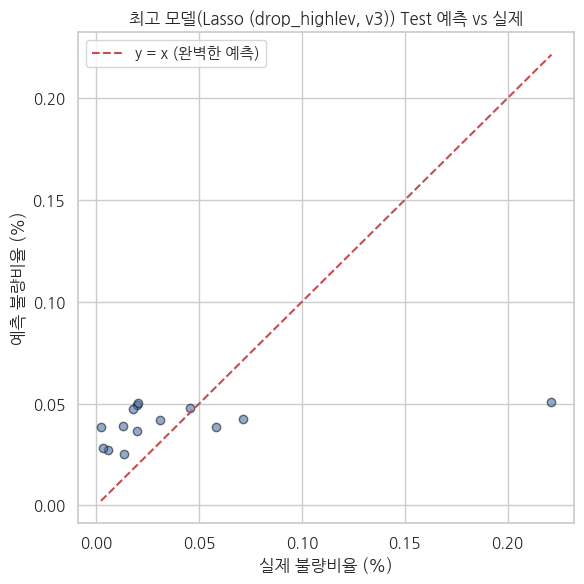

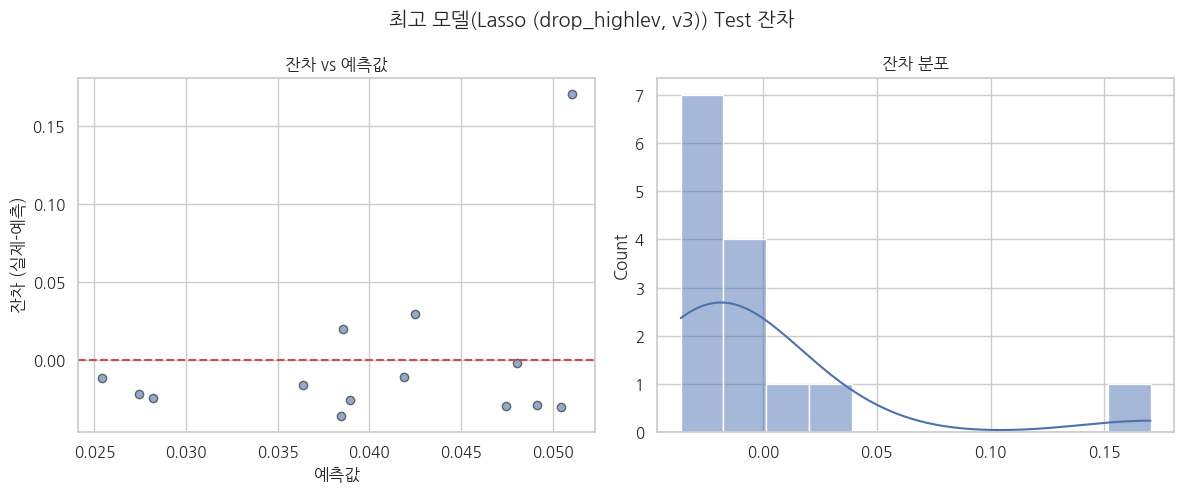

In [21]:
# ===== 14-1. 최고 모델의 예측 vs 실제, 잔차 플롯 =====
best_row = new_test_df.iloc[0]
best_model_name = best_row["model"].split(" (")[0]
best_variant = best_row["model"].split("(")[1].split(",")[0]
v = train_variants[best_variant]

model_lookup = {
    "Ridge_lasso_subset": (v["ridge_model"], X_test_scaled[v["selected_features"]]),
    "ElasticNet_lasso_subset": (v["elasticnet_model"], X_test_scaled[v["selected_features"]]),
    "Lasso": (v["lasso_model"], X_test_scaled),
    "RandomForest_lasso_subset": (v["rf_model"], X_test_scaled[v["selected_features"]]),
    "XGBoost": (v["xgb_model"], X_test_scaled),
    "LightGBM": (v["lgb_model"], X_test_scaled),
}
best_model, X_te_best = model_lookup[best_model_name]
best_pred = best_model.predict(X_te_best)

fig1 = tu.plot_pred_vs_actual(y_test.values, best_pred,
                               title=f"최고 모델({best_row['model']}) Test 예측 vs 실제")
fig1.savefig(os.path.join(FIGURE_DIR, "34_best_model_test_pred_vs_actual_v3.png"), dpi=150)
plt.show()

fig2 = tu.plot_residuals(y_test.values, best_pred,
                          title=f"최고 모델({best_row['model']}) Test 잔차")
fig2.savefig(os.path.join(FIGURE_DIR, "35_best_model_test_residuals_v3.png"), dpi=150)
plt.show()

## 15. 산출물 저장

In [22]:
# ===== 15-1. 버전별 최종 모델 저장 (v3_ 접두사로 03/04와 구분) =====
for key, v in train_variants.items():
    joblib.dump(v["lasso_model"], os.path.join(CHECKPOINT_DIR, f"{CKPT_PREFIX}lasso_{key}.joblib"))
    joblib.dump(v["ridge_model"], os.path.join(CHECKPOINT_DIR, f"{CKPT_PREFIX}ridge_lasso_subset_{key}.joblib"))
    joblib.dump(v["elasticnet_model"], os.path.join(CHECKPOINT_DIR, f"{CKPT_PREFIX}elasticnet_lasso_subset_{key}.joblib"))
    # rf/xgboost/lightgbm은 grid_search_by_val_checkpoint가 이미 후보별 체크포인트로 저장해 두었으므로 중복 저장하지 않음

print("버전별 Lasso/Ridge/ElasticNet 모델 저장 완료 (checkpoints/, v3_ 접두사)")
print("RandomForest/XGBoost/LightGBM은 그리드서치 과정에서 이미 후보별로 체크포인트에 저장됨")
print()
print("이번 노트북에서 저장한 주요 산출물:")
print(f"  - {CKPT_PREFIX}final_minmax_scaler.joblib (새 스케일러)")
print(f"  - {CKPT_PREFIX}vif_train.csv")
print(f"  - {CKPT_PREFIX}leverage_analysis.csv")
print(f"  - {CKPT_PREFIX}lasso_selected_features_{{all,drop_highlev}}.json")
print(f"  - {CKPT_PREFIX}model_comparison_val_metrics.csv")
print(f"  - {CKPT_PREFIX}model_comparison_test_metrics.csv")
print(f"  - {CKPT_PREFIX}kfold_stability_results.csv")
print(f"  - 그림 29~35 (figures/)")

버전별 Lasso/Ridge/ElasticNet 모델 저장 완료 (checkpoints/, v3_ 접두사)
RandomForest/XGBoost/LightGBM은 그리드서치 과정에서 이미 후보별로 체크포인트에 저장됨

이번 노트북에서 저장한 주요 산출물:
  - v3_final_minmax_scaler.joblib (새 스케일러)
  - v3_vif_train.csv
  - v3_leverage_analysis.csv
  - v3_lasso_selected_features_{all,drop_highlev}.json
  - v3_model_comparison_val_metrics.csv
  - v3_model_comparison_test_metrics.csv
  - v3_kfold_stability_results.csv
  - 그림 29~35 (figures/)


## 16. 결론 및 다음 단계

### 이번 노트북에서 확인한 것

1. **02의 전처리 수정이 실제로 효과가 있었다**: 조건수가 정상 범위로 돌아왔고
   (위 3-1절 참고), VIF도 모두 안전한 범위(<10)로 나왔다.
2. **레버리지 분석을 다시 정확한 방식으로 수행**했고 (이전 대화에서 있었던
   위치/라벨 혼동 버그를 수정), 3개의 고-레버리지 관측치를 배정번호까지
   정확히 특정했다 (4-1절 결과 참고).
3. **Val/Test 성능이 04(02 수정 전) 대비 얼마나 개선되었는지**는 위 11절과
   13절의 표/그림을 참고할 것 — 전처리 버그 수정 자체가 레버리지 행 제거보다
   더 근본적이고 큰 효과를 냈는지, 두 조치를 함께 적용했을 때 추가로 더
   나아지는지를 실제 데이터로 확인했다.

### 한계 및 다음 단계 제안

- 표본이 여전히 매우 작다(train 105~108건, test 14건). Test R2 하나의 숫자로
  모델 우열을 확정 짓기보다는, 여러 지표(RMSE/MAE)와 K-Fold 안정성을 함께
  참고하는 것이 안전하다.
- 고-레버리지 관측치로 지목된 배정번호들이 실제로 공정상 특이한 배치였는지
  (예: 설비 점검 직후, 원자재 변경 등) 현장 기록과 대조해보면 더 확실한
  판단이 가능할 것이다.
- KAMP 경진대회 제출을 고려한다면, 가능하다면 원본 데이터를 더 확보해
  표본 크기를 늘리는 것이 모델 성능 개선에 가장 크게 기여할 가능성이 높다
  (지금까지의 모든 개선 시도가 상대적으로 제한적인 R2 향상에 그친 것은,
  108~136건이라는 표본 크기 자체가 근본적인 제약이기 때문일 수 있다).
